# Battery Quality Classification

**Requirements:** Run `python train_clf.py` first to generate `./checkpoints_clf/best_clf.pt`

In [1]:
import numpy as np
import torch
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import joblib

from dataset_clf import (
    extract_clf_samples, load_all_npz,
    N_CLASSES, N_EARLY, N_RANDOM, N_INPUT,
    rul_to_class,
)
from train_clf import BatteryRULClassifier

# ── Config ──────────────────────────────────────────────────────────────────
DATA_DIR    = './content'
MODEL_PATH  = './checkpoints_clf/best_clf.pt'
DEVICE      = 'cuda' if torch.cuda.is_available() else 'cpu'

print(f'Device: {DEVICE}')

SUMMARY_FEATS = 16

CLASS_NAMES   = ["RUL>400", "RUL 300–400", "RUL 200–300", "RUL 100–200", "RUL<100"]
CLASS_COLORS  = ["#1565C0", "#2E7D32", "#F9A825", "#E65100", "#B71C1C"]

Device: cuda


## 1 — Load Data & Model

In [2]:
# Load all three .mat files
b1, b2, b3 = load_all_npz(DATA_DIR)
all_cells   = {**b1, **b2, **b3}
test_cells  = b3   # batch3 is the held-out test set


Loading .npz feature files...
Total — train: 94 cells  test: 44 cells



In [3]:
# Load trained model
model = BatteryRULClassifier(
        summary_feats = SUMMARY_FEATS,
        n_classes     = N_CLASSES).to(DEVICE)

model.load_state_dict(torch.load(MODEL_PATH, map_location=DEVICE))
model.eval().to(DEVICE)

dq_scaler      = joblib.load("./checkpoints_clf/dq_scaler.pkl")
summary_scaler = joblib.load("./checkpoints_clf/summary_scaler.pkl")
scalers        = (dq_scaler, summary_scaler)

n_params = sum(p.numel() for p in model.parameters())
print(f'Model loaded — {n_params:,} parameters')



Model loaded — 48,421 parameters


/var/tmp/ipykernel_58824/2361712743.py:6: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(MODEL_PATH, map_location=DEVICE))


## 2 — Prediction cell

In [4]:
@torch.no_grad()
def predict_cell(cell: dict, scalers = None):
    """
    Slide a 24-cycle window across the entire cell life.
    Returns arrays aligned to window end-cycle.
    """
    from dataset_clf import V_BINS, REF_CYCLE


    cycle_life = int(cell["cycle_life"])
    summary    = cell["summary"]
    qdlin_list = cell["qdlin"]
    

    qd  = np.array(summary["QDischarge"], dtype=np.float32).reshape(-1)
    ir  = np.array(summary["IR"],         dtype=np.float32).reshape(-1)
    tmx = np.array(summary["Tmax"],       dtype=np.float32).reshape(-1)
    tav = np.array(summary["Tavg"],       dtype=np.float32).reshape(-1)
    ct  = np.array(summary["chargetime"], dtype=np.float32).reshape(-1)
    dqdv_max = np.array(summary["dqdv_max"], dtype=np.float32).reshape(-1)
    dqdv_min = np.array(summary["dqdv_min"], dtype=np.float32).reshape(-1)
    dqdv_avg = np.array(summary["dqdv_avg"], dtype=np.float32).reshape(-1)
    log_std_dq = np.array(summary["log_std_dq"], dtype=np.float32).reshape(-1)
    log_std_T = np.array(summary["log_std_T"], dtype=np.float32).reshape(-1)
    log_std_ir = np.array(summary["log_std_ir"], dtype=np.float32).reshape(-1)
    log_std_ct = np.array(summary["log_std_ct"], dtype=np.float32).reshape(-1)

    n_cyc = min(len(qd) - 1, len(qdlin_list))   # usable cycles

    # need at least early + random window
    if n_cyc < N_INPUT:
        return []

    cap_ref = qd[1] if qd[1] > 0 else 1.1

    ref_qdlin = np.array(qdlin_list[REF_CYCLE], dtype=np.float32).reshape(-1)

    def get_dq(c):
        q      = np.array(qdlin_list[c], dtype=np.float32).reshape(-1)
        length = min(len(q), len(ref_qdlin), V_BINS)
        out    = np.zeros(V_BINS, dtype=np.float32)
        out[:length] = q[:length] - ref_qdlin[:length]
        return out
    
    def get_summary_row(c, d_pos=4):
        pos = c + 1
        def safe(arr):
            return float(arr[pos]) if pos < len(arr) else 0.0
        
        pe  = np.array([
            np.sin(pos / 3000 ** (2 * i / d_pos)) if i % 2 == 0 else
            np.cos(pos / 3000 ** ((2 * i - 1) / d_pos))
            for i in range(d_pos)
        ], dtype=np.float32)   # (4,)


        scalar_feats = np.array([
            safe(qd), safe(ir), safe(tmx), safe(tav), safe(ct),
            safe(dqdv_max), safe(dqdv_min), safe(dqdv_avg),
            safe(log_std_dq), safe(log_std_T), safe(log_std_ir), safe(log_std_ct),
        ], dtype=np.float32)   # (12,)

        return np.concatenate([scalar_feats, pe])   # (16,)

    end_cycles   = []
    pred_classes = []
    true_classes = []
    pred_probs   = []

    for start in range(N_EARLY, n_cyc - N_RANDOM):
        end_cycle     = start + N_RANDOM
        window_cycles = list(range(start, end_cycle))
        all_cycles    = list(range(N_EARLY)) + window_cycles

        dq_seq      = np.stack([get_dq(c)           for c in all_cycles])   # (32, 1000)
        summary_seq = np.stack([get_summary_row(c)   for c in all_cycles])   # (32, 16)
        
        # ── apply same scaling as training ──────────────────────────────
        if scalers is not None:
            dq_sc, sum_sc = scalers
            dq_seq      = dq_sc.transform(dq_seq)         # (32, 1000)
            summary_seq = sum_sc.transform(summary_seq)   # (32, 16)

        dq_t  = torch.tensor(dq_seq,      dtype=torch.float32).unsqueeze(0).to(DEVICE)
        sum_t = torch.tensor(summary_seq, dtype=torch.float32).unsqueeze(0).to(DEVICE)
        

        logits = model(dq_t, sum_t).squeeze(0)           # (N_CLASSES,)
        probs  = torch.softmax(logits, dim=-1).cpu().numpy()
        pred_c = int(probs.argmax())

        rul    = max(0, cycle_life - end_cycle)
        true_c = rul_to_class(rul)

        end_cycles.append(end_cycle)
        pred_classes.append(pred_c)
        true_classes.append(true_c)
        pred_probs.append(probs)

    return {
        "end_cycles":   np.array(end_cycles),
        "pred_classes": np.array(pred_classes),
        "true_classes": np.array(true_classes),
        "pred_probs":   np.array(pred_probs),    # (W, N_CLASSES)
        "cycle_life":   cycle_life,
        "accuracy":     float((np.array(pred_classes) == np.array(true_classes)).mean()),
    }

## 3 — Single Cell: Predicted vs Ground Truth

Cell: batch2c042
Sliding-window accuracy: 0.8105  (459 windows  cycle_life=466)
Saved: batch2c042_clf_prediction.png


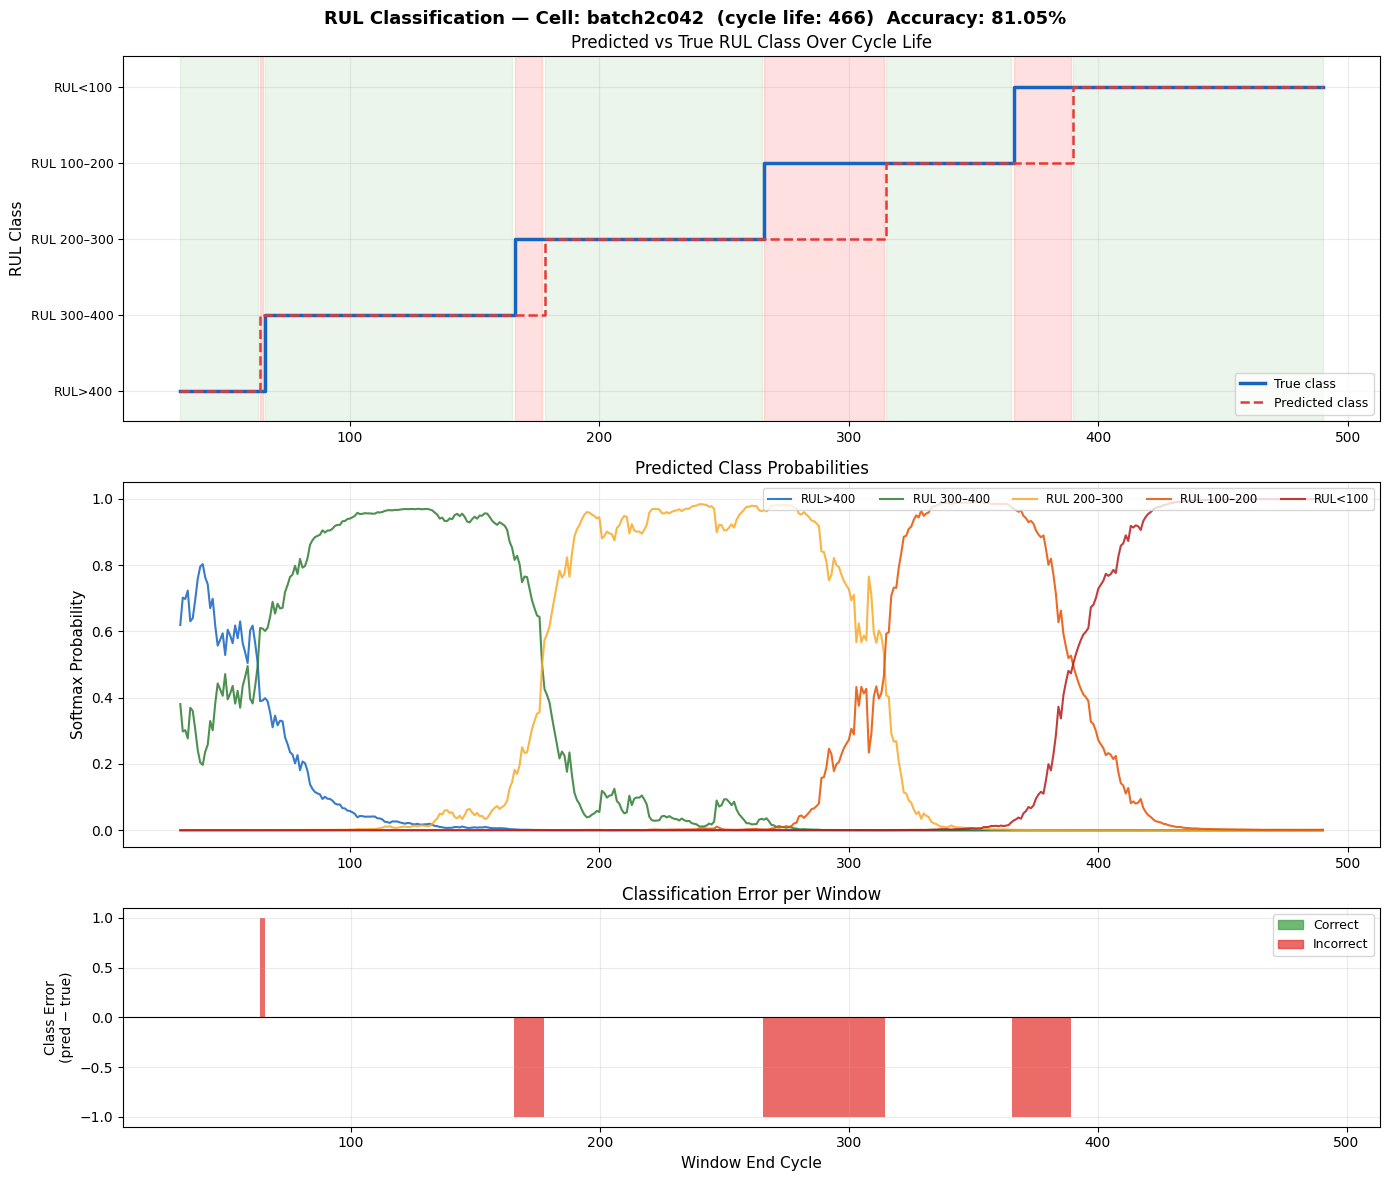

In [5]:
TestCellName = ['batch2c042', 'batch3c030', 'batch1c024', 'batch1c025', 'batch3c007', 'batch3c024', 'batch1c004', 
                'batch1c002', 'batch3c029', 'batch1c020', 'batch2c013', 'batch2c010', 'batch3c021', 'batch3c000', 
                'batch1c000', 'batch3c027', 'batch2c041', 'batch2c035', 'batch2c029', 'batch1c028', 'batch1c033', 
                'batch1c037', 'batch1c013', 'batch2c039', 'batch2c027', 'batch1c003', 'batch3c011']

CELL_ID      = 'batch2c042'
if CELL_ID is None:
    CELL_ID = list(b3.keys())[0]
print(f"Cell: {CELL_ID}")

cell       = all_cells[CELL_ID]
cycle_life = int(cell["cycle_life"])


res = predict_cell(cell, scalers=scalers)
print(f"Sliding-window accuracy: {res['accuracy']:.4f}  "
      f"({len(res['end_cycles'])} windows  cycle_life={res['cycle_life']})")

# ── Plot ─────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(3, 1, figsize=(14, 12),
                         gridspec_kw={"height_ratios": [2, 2, 1.2]})
fig.suptitle(f"RUL Classification — Cell: {CELL_ID}  "
             f"(cycle life: {res['cycle_life']})  "
             f"Accuracy: {res['accuracy']:.2%}",
             fontsize=13, fontweight="bold")

cycles      = res["end_cycles"]
pred_cls    = res["pred_classes"]
true_cls    = res["true_classes"]
pred_probs  = res["pred_probs"]

# ── Panel 1: predicted vs true class over cycle ───────────────────────────
ax = axes[0]
ax.step(cycles, true_cls, where="post", color="#1565C0", lw=2.5,
        label="True class", zorder=3)
ax.step(cycles, pred_cls, where="post", color="#E53935", lw=1.8,
        ls="--", label="Predicted class", zorder=4)
ax.set_yticks(range(N_CLASSES))
ax.set_yticklabels(CLASS_NAMES, fontsize=9)
ax.set_ylabel("RUL Class", fontsize=11)
ax.set_title("Predicted vs True RUL Class Over Cycle Life")
ax.legend(fontsize=9)
ax.grid(True, alpha=0.25)

# shade correct / incorrect windows
correct = pred_cls == true_cls
ax.fill_between(cycles, -0.4, N_CLASSES - 0.6,
                where=correct,  alpha=0.08, color="green",  step="post")
ax.fill_between(cycles, -0.4, N_CLASSES - 0.6,
                where=~correct, alpha=0.12, color="red",    step="post")
ax.set_ylim(-0.4, N_CLASSES - 0.6)

# ── Panel 2: predicted class probability over cycle ───────────────────────
ax = axes[1]
for c in range(N_CLASSES):
    ax.plot(cycles, pred_probs[:, c], color=CLASS_COLORS[c],
            lw=1.5, label=CLASS_NAMES[c], alpha=0.85)
ax.set_ylabel("Softmax Probability", fontsize=11)
ax.set_title("Predicted Class Probabilities")
ax.legend(fontsize=8.5, ncol=N_CLASSES, loc="upper right")
ax.grid(True, alpha=0.25)
ax.set_ylim(-0.05, 1.05)

# ── Panel 3: error (mismatch) ─────────────────────────────────────────────
ax = axes[2]
error = pred_cls - true_cls
ax.bar(cycles, error, width=1.0,
       color=["#E53935" if e != 0 else "#43A047" for e in error],
       alpha=0.75)
ax.axhline(0, color="black", lw=0.8)
ax.set_xlabel("Window End Cycle", fontsize=11)
ax.set_ylabel("Class Error\n(pred − true)", fontsize=10)
ax.set_title("Classification Error per Window")
ax.grid(True, alpha=0.25)

# legend patches
patches = [
    mpatches.Patch(color="#43A047", alpha=0.75, label="Correct"),
    mpatches.Patch(color="#E53935", alpha=0.75, label="Incorrect"),
]
ax.legend(handles=patches, fontsize=9)

plt.tight_layout()
out_path = f"{CELL_ID}_clf_prediction.png"
plt.savefig(out_path, dpi=150, bbox_inches="tight")
print(f"Saved: {out_path}")
plt.show()

## 4 — All Test Cells

In [ ]:
# ── Run inference on ALL cells ────────────────────────────────────────────────
from matplotlib.lines import Line2D
import matplotlib.patches as mpatches

print("Running inference on all cells...")
all_results = {}

MaxPlot = 20

for cid, cell in all_cells.items():
    r = predict_cell(cell, scalers=scalers)
    if r is not None and len(r["end_cycles"]) > 0:
        all_results[cid] = r
print(f"Predicted {len(all_results)} cells")

# ── Grid plot ─────────────────────────────────────────────────────────────────
n     = len(all_results)
ncols = 5
nrows = (n + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 3.5, nrows * 3),
                         constrained_layout=True)
fig.suptitle("All Cells — Predicted vs True RUL Class Over Cycle Life",
             fontsize=14, fontweight="bold", y=1.01)

axes_flat = axes.flatten() if n > 1 else [axes]

for ax, (cid, r) in zip(axes_flat, all_results.items()):
    cyc      = r["end_cycles"]
    pred_cls = r["pred_classes"]
    true_cls = r["true_classes"]
    correct  = pred_cls == true_cls

    ax.step(cyc, true_cls, where="post", color="#1565C0", lw=1.8)
    ax.step(cyc, pred_cls, where="post", color="#E53935", lw=1.4, ls="--")

    ax.fill_between(cyc, -0.4, N_CLASSES - 0.6,
                    where=correct,  alpha=0.08, color="green", step="post")
    ax.fill_between(cyc, -0.4, N_CLASSES - 0.6,
                    where=~correct, alpha=0.14, color="red",   step="post")

    ax.set_yticks(range(N_CLASSES))
    ax.set_yticklabels(["R>400", "R>300", "R>200", "R>100", "R<100"], fontsize=5)
    ax.set_ylim(-0.4, N_CLASSES - 0.6)
    ax.set_title(f"{cid}\nacc={r['accuracy']:.2%}", fontsize=7.5)
    ax.tick_params(labelsize=6)
    ax.grid(True, alpha=0.2)

for ax in axes_flat[len(all_results):]:
    ax.set_visible(False)

legend_elements = [
    Line2D([0], [0], color="#1565C0", lw=1.8,          label="True class"),
    Line2D([0], [0], color="#E53935", lw=1.4, ls="--", label="Pred class"),
    mpatches.Patch(color="green", alpha=0.2,            label="Correct"),
    mpatches.Patch(color="red",   alpha=0.25,           label="Incorrect"),
]
fig.legend(handles=legend_elements, loc="lower center",
           ncol=4, fontsize=9, bbox_to_anchor=(0.5, -0.02))

plt.savefig("all_cells_clf.png", dpi=130, bbox_inches="tight")
plt.show()

# ── Summary stats ─────────────────────────────────────────────────────────────
accs = [r["accuracy"] for r in all_results.values()]
print(f"\nAll-cell accuracy  mean={np.mean(accs):.4f}  "
      f"std={np.std(accs):.4f}  "
      f"min={np.min(accs):.4f}  "
      f"max={np.max(accs):.4f}")

Running inference on all cells...


## 5 — All cells overlay — coloured by cycle life

In [ ]:
from matplotlib import cm

cycle_lives = [r["cycle_life"] for r in all_results.values()]
vmin, vmax  = min(cycle_lives), max(cycle_lives)
cmap        = cm.get_cmap("plasma")

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))
fig.suptitle("All Cells Overlay — Predicted vs True RUL Class, Coloured by Cycle Life",
             fontsize=13, fontweight="bold")

for ax, key in zip(axes, ["true_classes", "pred_classes"]):
    label = "Ground Truth" if key == "true_classes" else "Predicted"
    for r in all_results.values():
        cyc   = r["end_cycles"]
        color = cmap((r["cycle_life"] - vmin) / (vmax - vmin + 1e-9))
        ax.step(cyc, r[key], where="post", color=color, alpha=0.6, lw=1.2)

    ax.set_yticks(range(N_CLASSES))
    ax.set_yticklabels(CLASS_NAMES, fontsize=8)
    ax.set_ylim(-0.4, N_CLASSES - 0.6)
    ax.set_title(label, fontsize=12)
    ax.set_xlabel("Window End Cycle", fontsize=11)
    ax.set_ylabel("RUL Class", fontsize=11)
    ax.grid(True, alpha=0.2)

sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=vmin, vmax=vmax))
sm.set_array([])
cbar = fig.colorbar(sm, ax=axes, fraction=0.02, pad=0.02)
cbar.set_label("Cycle Life", fontsize=11)

plt.savefig("overlay_all_cells_clf.png", dpi=150, bbox_inches="tight")
plt.show()

## 6 — EOL estimation from sliding-window prediction

In [ ]:
# ── EOL estimation from sliding-window predictions ────────────────────────────
# EOL = first window-end cycle where predicted/true class == 4 (RUL < 100)

eol_true_list, eol_pred_list, cid_list = [], [], []

for cid, r in all_results.items():
    cycles   = r["end_cycles"]
    true_cls = r["true_classes"]
    pred_cls = r["pred_classes"]

    # true EOL: first cycle where true class == 4, fallback to cycle_life
    true_hits = cycles[true_cls == 4]
    eol_true  = int(true_hits[0]) if len(true_hits) > 0 else r["cycle_life"]

    # pred EOL: first cycle where predicted class == 4, fallback to last cycle
    pred_hits = cycles[pred_cls == 4]
    eol_pred  = int(pred_hits[0]) if len(pred_hits) > 0 else int(cycles[-1])

    eol_true_list.append(eol_true)
    eol_pred_list.append(eol_pred)
    cid_list.append(cid)

eol_true = np.array(eol_true_list)
eol_pred = np.array(eol_pred_list)
eol_err  = eol_pred - eol_true

mae_eol  = float(np.mean(np.abs(eol_err)))
mape_eol = float(np.mean(np.abs(eol_err) / (eol_true + 1e-6)) * 100)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("End-of-Life Estimation from RUL Classification", fontsize=13, fontweight="bold")

# ── Parity plot ───────────────────────────────────────────────────────────────
ax  = axes[0]
lim = [min(eol_true.min(), eol_pred.min()) - 50,
       max(eol_true.max(), eol_pred.max()) + 50]

sc = ax.scatter(eol_true, eol_pred, c=np.abs(eol_err),
                cmap="RdYlGn_r", s=60, edgecolors="k", linewidths=0.4, zorder=3)
plt.colorbar(sc, ax=ax, label="|EOL error| (cycles)")
ax.plot(lim, lim, "k--", lw=1.2, label="Perfect prediction")
ax.fill_between(lim, [l - 100 for l in lim], [l + 100 for l in lim],
                alpha=0.1, color="green", label="±100 cycle band")
ax.set_xlabel("True EOL (cycles)",      fontsize=11)
ax.set_ylabel("Predicted EOL (cycles)", fontsize=11)
ax.set_title("EOL Parity Plot\n(first cycle predicted as RUL < 100)")
ax.set_xlim(lim); ax.set_ylim(lim)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.25)
ax.text(0.04, 0.92, f"MAE = {mae_eol:.1f} cycles\nMAPE = {mape_eol:.1f}%",
        transform=ax.transAxes, fontsize=10,
        bbox=dict(boxstyle="round", facecolor="white", alpha=0.85))

# ── Error histogram ───────────────────────────────────────────────────────────
ax = axes[1]
ax.hist(eol_err, bins=20, color="#1976D2", edgecolor="white", linewidth=0.6)
ax.axvline(0,              color="black", lw=1.5, ls="--", label="Zero error")
ax.axvline(eol_err.mean(), color="red",   lw=1.5, ls="-",
           label=f"Mean error = {eol_err.mean():.1f} cycles")
ax.set_xlabel("EOL Prediction Error (pred − true cycles)", fontsize=11)
ax.set_ylabel("Count", fontsize=11)
ax.set_title("EOL Error Distribution")
ax.legend(fontsize=9)
ax.grid(True, alpha=0.25)

plt.tight_layout()
plt.savefig("eol_parity_clf.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Cells evaluated : {len(eol_true)}")
print(f"EOL MAE         : {mae_eol:.1f} cycles")
print(f"EOL MAPE        : {mape_eol:.1f}%")
print(f"Mean error      : {eol_err.mean():.1f} cycles  (+ = over-predict)")
print(f"Std error       : {eol_err.std():.1f} cycles")

## 7 — Per-Cell Summary Table

In [ ]:
# ── Per-cell results table ─────────────────────────────────────────────────────
print(f'{"Cell":>12} | {"CycLife":>7} | {"EOL_True":>8} | {"EOL_Pred":>8} | '
      f'{"EOL_Err":>8} | {"Acc":>7}')
print('-' * 62)

for cid in sorted(all_results.keys()):
    r        = all_results[cid]
    cycles   = r["end_cycles"]
    true_cls = r["true_classes"]
    pred_cls = r["pred_classes"]

    true_hits = cycles[true_cls == 4]
    eol_t     = int(true_hits[0]) if len(true_hits) > 0 else r["cycle_life"]

    pred_hits = cycles[pred_cls == 4]
    eol_p     = int(pred_hits[0]) if len(pred_hits) > 0 else int(cycles[-1])

    err = eol_p - eol_t
    print(f'{cid:>12} | {r["cycle_life"]:7d} | {eol_t:8d} | '
          f'{eol_p:8d} | {err:+8d} | {r["accuracy"]:7.2%}')

print('-' * 62)
print(f'{"MEAN":>12} | {"":>7} | {"":>8} | {"":>8} | '
      f'{eol_err.mean():+8.1f} | {np.mean([r["accuracy"] for r in all_results.values()]):7.2%}')
print(f'{"MAE":>12} | {"":>7} | {"":>8} | {"":>8} | '
      f'{mae_eol:8.1f} | ')
print(f'{"MAPE":>12} | {"":>7} | {"":>8} | {"":>8} | '
      f'{mape_eol:7.1f}% | ')